# Unstructured mesh R2S shutdown dose rate with different materials

In this example, we perform a shutdown dose rate simulation using the R2S method on an unstructured mesh.

This is an upgraded example that includes three cells, three materials (instead of one) and two cooling timesteps

When material regions are in contact, it's possible for a single tetrahedral element to contain multiple materials. This must be carefully accounted for when depleting the element volume

First, we import all the necessary packages for the simulation.

In [1]:
from cad_to_dagmc import CadToDagmc
import cadquery as cq
import openmc
from matplotlib.colors import LogNorm
import openmc.deplete
from pathlib import Path

Then we sets the cross section path to the correct location in the docker image.
If you are running this outside the docker image you will have to change this path to your local cross section path.

In [2]:
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

makes a CAD geometry to use for the neutronics geometry

three volumes and three material tags, one for each letter

In [3]:
text = cq.Workplane().text(txt="R2S", fontsize=10, distance=1)

my_model = CadToDagmc()
my_model.add_cadquery_object(
    cadquery_object=text,
    material_tags=[
        "mat1",
        "mat2",
        "mat3",
    ],
)

Fontconfig error: Cannot load default config file: No such file: (null)


3

Convert the CAD geometry to a DAGMC surface mesh and MOAB volume mesh. This conversion ensures that the surface mesh matches the outer surface of the volume mesh. This helps ensure that tetrahedral elements have a single material within.

In [4]:
dagmc_filename, umesh_filename = my_model.export_dagmc_h5m_file(
    filename="dagmc.h5m",
    max_mesh_size=10,
    min_mesh_size=2,
    unstructured_volumes=[1,2,3],
    umesh_filename="umesh.vtk",
)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 3 (Bezier)
Info    : [  0%] Meshing curve 2 (Line)
Info    : [  0%] Meshing curve 4 (Bezier)
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 9 (Line)
Info    : [  0%] Meshing curve 6 (Bezier)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 12 (Line)
Info    : [  0%] Meshing curve 13 (Line)
Info    : [  0%] Meshing curve 10 (Line)
Info    : [  0%] Meshing curve 7 (Bezier)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 15 (Line)
Info    : [  0%] Meshing curve 16 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%] Meshing curve 18 (Bezier)
Info    : [  0%] Meshing curve 19 (Bezier)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 21 (Bezier)
Info    : [  0%] Meshing curve 22 (Bezier)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing c

Now use the two meshes in OpenMC to make the DAGMCUniverse and the UnstructuredMesh

We transport particles on the DAGMCUniverse

We will get the flux on the UnstructuredMesh tets and then activate the materials on each tet and use this information to make source terms

In [5]:
# add adding distance to avoid source being born on edge of geometry and the 2nd simulation crashing
universe = openmc.DAGMCUniverse("dagmc.h5m").bounded_universe()
my_geometry = openmc.Geometry(universe)

# the unstructured mesh to overlay on the DAGMC geometry
umesh = openmc.UnstructuredMesh("umesh.vtk", library="moab")

Define the materials used in the simulation.

The number of material names must match the number of tags included in the DAGMC file.

In [6]:
fe_material = openmc.Material(name='mat1')
fe_material.add_nuclide("Fe56", 1, percent_type="ao") 
fe_material.set_density("g/cm3", 7.874)
fe_material.depletable = True

Li4SiO4_mat = openmc.Material(name='mat2')
Li4SiO4_mat.add_element('Li', 4.0, percent_type='ao')
Li4SiO4_mat.add_element('Si', 1.0, percent_type='ao')
Li4SiO4_mat.add_element('O', 4.0, percent_type='ao')
Li4SiO4_mat.set_density('g/cm3', 2.32) 
Li4SiO4_mat.depletable = True

water_mat = openmc.Material(name='mat3')
water_mat.add_element('H', 2.0, percent_type='ao')
water_mat.add_element('O', 1.0, percent_type='ao')
water_mat.set_density('g/cm3', 0.99821) 
water_mat.depletable = True


my_materials = openmc.Materials([fe_material, Li4SiO4_mat, water_mat])

Make a simple neutron source in the center of the geometry

In [7]:
# Create a DT point source
my_source = openmc.IndependentSource()
my_source.space = openmc.stats.Point(my_geometry.bounding_box.center)
my_source.angle = openmc.stats.Isotropic()
my_source.energy = openmc.stats.Discrete([14e6], [1])

Make the simulation settings for the neutron irradiation

In [8]:
my_settings = openmc.Settings()
my_settings.batches = 5
my_settings.particles = 5000
my_settings.run_mode = "fixed source"
my_settings.output = {'summary': False}
my_settings.source = my_source

Make the neutron irradiation model

In [9]:
model = openmc.model.Model(my_geometry, my_materials, my_settings) 
model.export_to_xml()

Collect a list of all nuclides present in the model

Get the flux and micro_xs in each unstructured mesh tet

In [10]:
all_nuclides = set()
for material in my_materials:
    all_nuclides.update(material.get_nuclides())

! rm statepoint.5.h5

flux_in_each_voxel, micro_xs = openmc.deplete.get_microxs_and_flux(
    model=model,
    domains=umesh,
    energies=[0, 30e6], # one energy bin from 0 to 30MeV
    chain_file=openmc.config['chain_file'],
    # needed otherwise the statepoint file is produced in an unknown temporary directory
    run_kwargs={'cwd':'.'},
    nuclides=list(all_nuclides)  # Convert set to list
)

rm: cannot remove 'statepoint.5.h5': No such file or directory


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading cross sections XML file...
Using the DOUBLE-DOWN interface to Embree.
Loading file /home/jon/neutronics-workshop/tasks/task_20_CAD_shut_down_dose_rate/dagmc.h5m
Initializing the GeomQueryTool...
Using faceting tolerance: 2.27977e-315
Building acceleration data structures...
 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5


 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5
 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading Si28 from /home/jon/nuclear_data/neutron/Si28.h5


 Reading Si29 from /home/jon/nuclear_data/neutron/Si29.h5


...

 Simulating batch 3


 Simulating batch 4


 Simulating batch 5


 Creating state point statepoint.5.h5...
          Please use the Python API to generated the desired VTK tetrahedral
          mesh.
          Please use the Python API to generated the desired VTK tetrahedral
          mesh.



 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 2.4086e+00 seconds
   Reading cross sections          = 1.0926e+00 seconds
 Total time in simulation          = 1.4658e+00 seconds
   Time in transport only          = 1.3866e+00 seconds
   Time in active batches          = 1.4658e+00 seconds
   Time accumulating tallies       = 1.7176e-02 seconds
   Time writing statepoints        = 6.0946e-02 seconds
 Total time for finalization       = 2.0420e-01 seconds
 Total time elapsed                = 4.0853e+00 seconds
 Calculation Rate (active)         = 17056.0 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.99683 +/- 0.00019



Read in the unstructured from the statepoint, this contains additional information (centroids and volumes) compared to the umesh object

In [11]:
sp_filename=f'statepoint.{my_settings.batches}.h5'
sp = openmc.StatePoint(sp_filename)

# normally with regular meshes I would get the mesh from the tally
# but with unstructured meshes the tally does not contain the mesh
# however we can get it from the statepoint file
umesh_from_sp = sp.meshes[umesh.id]
# reading a unstructured mesh from the statepoint trigger internal code in the mesh
#  object so that its centroids and volumes become known.
# centroids and volumes are needed for the get_values and write_data_to_vtk steps
centroids = umesh_from_sp.centroids
mesh_vols = umesh_from_sp.volumes

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)


Calcualte the material volumes for each mesh element from the unstructured mesh

In [12]:
mat_vols = umesh_from_sp.material_volumes(model=model,n_samples=1_000_000)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading cross sections XML file...
Using the DOUBLE-DOWN interface to Embree.
Loading file /home/jon/neutronics-workshop/tasks/task_20_CAD_shut_down_dose_rate/dagmc.h5m
Initializing the GeomQueryTool...
Using faceting tolerance: 0
Building acceleration data structures...
 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5
 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5
 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading Si28 from /home/jon/nuclear_data/neutron/Si28.h5
 Reading Si29 from /home/jon/nuclear_data/neutron/Si29.h5
 Reading Si30 from /home/jon/nuclear_data/neutron/Si30.h5
 Reading O16 from /home/jon/nuclear_data/neutron/O16.h5
 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5
 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5
 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Minimum neutron data temperature: 1.7976931348623157e+308 K
 Maximum neutron data temperature: 0.0 K
 Gett

 Preparing distributed cell instances...

 ===============>     MESH MATERIAL VOLUMES CALCULATION     <===============

 Number of mesh elements = 858
 Number of rays (x) = 1420
 Number of rays (y) = 593
 Number of rays (z) = 78
 Total number of rays = 999074
 Table size per mesh element = 8



 =======================>     TIMING STATISTICS     <=======================

 Total time elapsed            = 4.3519e+01 seconds
   Ray tracing                 = 4.3517e+01 seconds
   MPI communication           = 0.0000e+00 seconds
   Normalization               = 2.1676e-03 seconds
 Calculation rate              = 2.2958e+04 rays/seconds
 Calculation rate (per thread) = 1.4349e+03 rays/seconds


Make a new fresh material for every tet in the unstructured mesh.

Assign the material volume for each tet as the volume is needed to deplete the material.

In [13]:
# Get material IDs from my_materials object
material_ids = [mat.id for mat in my_materials]

materials_for_every_mesh_voxel = []
for i in range(len(mat_vols[material_ids[0]])):
    # Find which material is present in this voxel (only one material per voxel)
    material_id = next(mid for mid in material_ids if mat_vols[mid][i] > 0)
    material = next(mat for mat in my_materials if mat.id == material_id)
    
    # Create a new material instance for this voxel
    new_mat = material.clone()
    new_mat.id = i
    # Use the volume of this material in this voxel from mat_vol
    new_mat.volume = mat_vols[material_id][i]
    materials_for_every_mesh_voxel.append(new_mat) 

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=6.
  warn(msg, IDWarning)
/home/jon/

/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=799.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=800.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=801.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=802.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=803.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=804.
  warn(msg, IDWarning

Define irradiation and cooling time steps.

Set source rates to zero during decay-only steps.


In [14]:
timesteps_and_source_rates = [
    (5, 1e20),  # 5 second  
    (60, 0),  # 60 seconds
    (60, 0) # 60 seconds
]

timesteps = [item[0] for item in timesteps_and_source_rates]
source_rates = [item[1] for item in timesteps_and_source_rates]

Perform the activation / depletion / transmutation of all the materials

In [15]:
# constructing the operator, note we pass in the flux and micro xs
operator = openmc.deplete.IndependentOperator(
    materials=openmc.Materials(materials_for_every_mesh_voxel),
    fluxes=[flux[0] for flux in flux_in_each_voxel],  # Flux in each group in [n-cm/src] for each domain
    micros=micro_xs,
    reduce_chain_level=5,
    normalization_mode="source-rate"
)

integrator = openmc.deplete.PredictorIntegrator(
    operator=operator,
    timesteps=timesteps,
    source_rates=source_rates, # a 5 second pulse of neutrons followed by 120 seconds of decay
    timestep_units='s'
)

integrator.integrate()

[openmc.deplete] t=0.0 s, dt=5 s, source=1e+20


[openmc.deplete] t=5.0 s, dt=60 s, source=0.0


/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=65.0 s, dt=60 s, source=0.0


[openmc.deplete] t=125.0 (final operator evaluation)


Make a dose tally on a regular mesh for the photon / gamma dose.

The tallies will be used in each of the gamma simulations to see the shutdown dose

In [16]:
energies, pSv_cm2 = openmc.data.dose_coefficients(particle="photon", geometry="AP")
dose_filter = openmc.EnergyFunctionFilter(
    energies, pSv_cm2, interpolation="cubic"  # interpolation method recommended by ICRP
)

regularmesh = openmc.RegularMesh().from_domain(
    my_geometry,
    dimension=[30, 30, 30],  # 30 voxels in each axis direction (x, y, z)
)

particle_filter = openmc.ParticleFilter(["photon"])
mesh_filter = openmc.MeshFilter(regularmesh)
dose_tally = openmc.Tally()
dose_tally.filters = [mesh_filter, dose_filter, particle_filter]
dose_tally.scores = ["flux"]
dose_tally.name = "photon_dose_on_mesh"
tallies = openmc.Tallies([dose_tally])

We will collect the gamma source for all cooling time steps

Extract all the materials and get their gamma emission spectrum

Turn these gamma spectra into source terms for later use

In [17]:
results = openmc.deplete.Results.from_hdf5("depletion_results.h5")

all_mesh_sources = []
for i_cool in range(1,len(timesteps)):  # skip the first time step as it is the irradiation step
    all_sources = []
    for i, mesh_vol in enumerate(mesh_vols):
        material_id = str(i)

        activated_material = results[i_cool].get_material(material_id)
        activated_material.volume = mesh_vol
        energy = activated_material.get_decay_photon_energy(
            clip_tolerance = 1e-6,
            units = 'Bq',
        )

        if energy:
            strength = energy.integral()
        # for the strength == None case
        else:
            strength = 0

        my_source = openmc.IndependentSource(
            energy=energy,
            particle = "photon",
            strength = strength,
            # constraints={'domains':my_material}
        )

        all_sources.append(my_source)

    # Make a mesh source out of the IndependentSource just made in the inner loop
    mesh_source = openmc.MeshSource(
        mesh=umesh_from_sp,
        sources=all_sources,
    )

    all_mesh_sources.append(mesh_source)


/home/jon/.neutronicsworkshop/lib/python3.11/site-packages/openmc/deplete/results.py:94: FutureWarning: The ResultsList.from_hdf5(...) method is no longer necessary and will be removed in a future version of OpenMC. Use Results(...) instead.
  warn(


Makes and runs a simulation model for each time meshsource that has been made.

In [18]:
#Make simulation settings for the gamma transport simulation
my_gamma_settings = openmc.Settings()
my_gamma_settings.run_mode = "fixed source"
my_gamma_settings.batches = 10
my_gamma_settings.particles = 1000000
my_gamma_settings.output = {'summary': False}
my_gamma_settings.photon_transport = True

all_gamma_sp_filename = []

for mesh_source in all_mesh_sources:
    
    my_gamma_settings.source = mesh_source

    # here we use the same pristine materials from before neutron irradaiton as the burnup is low
    # and the materials have not changed much so they would not perterb the neutron spectrum significantly
    # you could also use the activated materials from the depletion results but this would significantly slow the simulation down
    model_gamma = openmc.Model(my_geometry, my_materials, my_gamma_settings, tallies)

    # Make the model for the gamma / photon transport and run the simulation
    # a folder will be made for each photon transposrt, XML files will be saves there as well as the plot
    # Create directories with parents=True to ensure parent directories are created
    output_dir = Path(f"photons/photon_at_time_{i_cool}")
    output_dir.mkdir(parents=True, exist_ok=True)

    gamma_sp_filename = model_gamma.run(cwd=str(output_dir))
    all_gamma_sp_filename.append(gamma_sp_filename)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading cross sections XML file...
Using the DOUBLE-DOWN interface to Embree.
Loading file /home/jon/neutronics-workshop/tasks/task_20_CAD_shut_down_dose_rate/dagmc.h5m
Initializing the GeomQueryTool...
Using faceting tolerance: 3.34304e-315
Building acceleration data structures...
 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5


 Reading Fe from /home/jon/nuclear_data/photon/Fe.h5 
 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5
 Reading Li from /home/jon/nuclear_data/photon/Li.h5 
 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading Si28 from /home/jon/nuclear_data/neutron/Si28.h5


 Reading Si from /home/jon/nuclear_data/photon/Si.h5 
 Reading Si29 from /home/jon/nuclear_data/neutron/Si29.h5


 Reading Si30 from /home/jon/nuclear_data/neutron/Si30.h5
 Reading O16 from /home/jon/nuclear_data/neutron/O16.h5
 Reading O from /home/jon/nuclear_data/photon/O.h5 


...

 Simulating batch 7


 Simulating batch 8


 Simulating batch 9


 Simulating batch 10


 Creating state point statepoint.10.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 1.4430e+00 seconds
   Reading cross sections          = 1.1163e+00 seconds
 Total time in simulation          = 4.7585e+01 seconds
   Time in transport only          = 4.7501e+01 seconds
   Time in active batches          = 4.7585e+01 seconds
   Time accumulating tallies       = 4.5879e-02 seconds
   Time writing statepoints        = 3.2947e-02 seconds
 Total time for finalization       = 1.0052e-01 seconds
 Total time elapsed                = 4.9131e+01 seconds
 Calculation Rate (active)         = 210150.0 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 1.00332 +/- 0.00001



Loads up each of the simulation and plots the results

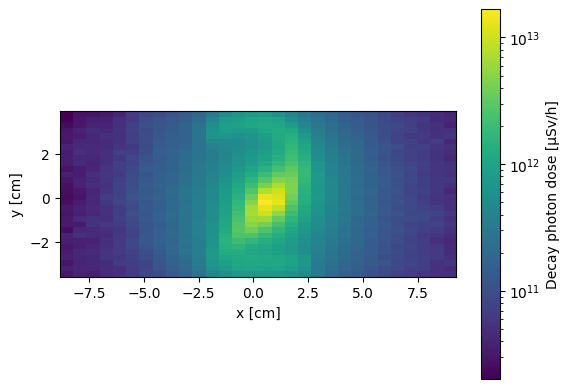

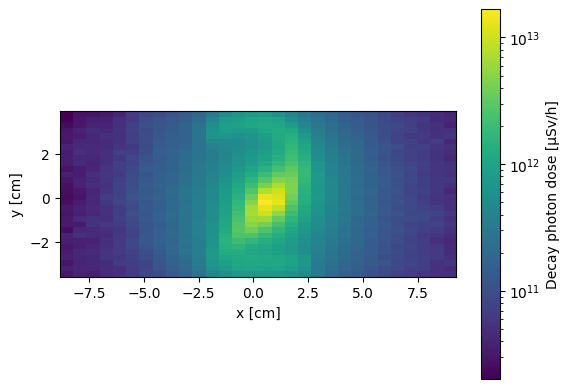

In [19]:
from openmc_regular_mesh_plotter import plot_mesh_tally

for gamma_sp_filename in all_gamma_sp_filename:
# You may wish to plot the dose tally on a mesh, this package makes it easy to include the geometry with the mesh tally
    with openmc.StatePoint(gamma_sp_filename) as statepoint:
        photon_tally = statepoint.get_tally(name="photon_dose_on_mesh")

        pico_to_micro = 1e-6
        seconds_to_hours = 60*60
        scaling_factor = (seconds_to_hours * pico_to_micro) / regularmesh.volumes[0][0][0]

        plot = plot_mesh_tally(
                tally=photon_tally,
                basis="xy",
                # score='flux', # only one tally so can make use of default here
                value="mean",
                colorbar_kwargs={
                    'label': "Decay photon dose [µSv/h]",
                },
                norm=LogNorm(),
                volume_normalization=False,
                scaling_factor=scaling_factor,
            )
        plot.figure.savefig(output_dir / f'shut_down_dose_map_timestep_{i_cool}.png')

You may want to increase the resolution of the regularmesh and rerun the simulation

I can also recommend talking a look shutdown dose rate simulations using the D1S

D1S is generally quicker than R2S.

R2S allows the user the possibility of changing the geometry between the neutron and gamma simulation.
This can be useful for doing shutdown dose rate simulations with moving geometry of geometry that has been irradiated in one position then moved for maintenance and is still active.